In [151]:
import steps.preprocess as preproc
import steps.edge_detector as edge_detector
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [152]:
def plot(img, title):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

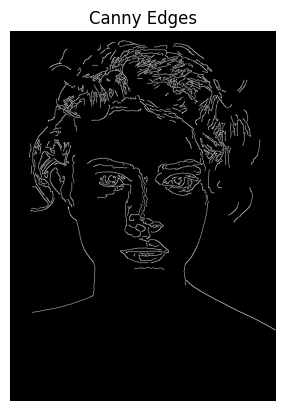

In [174]:
img, gray_img, bf_img, bf_gray = preproc.preprocess("sample_images/portrait1.jpg")

edges = edge_detector.canny_edge_detector(bf_gray, percentageOfNonEdge=0.95)

plot(edges, 'Canny Edges')

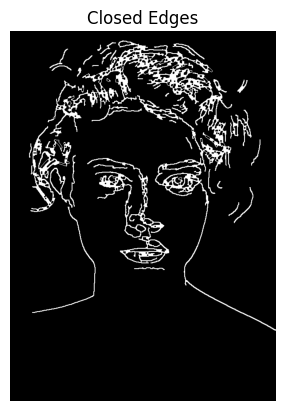

In [175]:
import cv2
import numpy as np

# Small dilation only — just to thicken edges slightly
kernel = np.ones((2, 2), np.uint8)
dilated = cv2.dilate(edges, kernel, iterations=1)

# Find all contours from the thin edges
contours, _ = cv2.findContours(dilated, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)

canvas = np.zeros_like(dilated)

for cnt in contours:
    # Skip tiny noise contours
    if len(cnt) < 10:
        continue

    pts = cnt[:, 0, :]  # shape (N, 2)

    # Measure the gap between first and last point
    gap = np.linalg.norm(pts[0].astype(float) - pts[-1].astype(float))

    if gap < 8000:
        # Small gap — just draw the contour and stitch endpoints
        cv2.drawContours(canvas, [cnt], -1, 255, 1)
        cv2.line(canvas, tuple(pts[-1]), tuple(pts[0]), 255, 1)

    else:
        # Large gap — use convex hull to force a closed shape
        hull = cv2.convexHull(cnt)
        cv2.drawContours(canvas, [hull], -1, 255, 1)

# Final small close to catch any remaining pixel-level breaks
kernel_tiny = np.ones((3, 3), np.uint8)
final = cv2.morphologyEx(canvas, cv2.MORPH_CLOSE, kernel_tiny, iterations=1)

plot(final, 'Closed Edges')

In [154]:
from itertools import combinations

binary = edges // 255  # 0s and 1s, easier for neighbor counting

# Count 8-connected neighbors for every edge pixel
kernel = np.ones((3, 3), dtype=np.uint8)
kernel[1, 1] = 0  # don't count the pixel itself

neighbor_count = cv2.filter2D(binary.astype(np.float32), -1, kernel.astype(np.float32))
neighbor_count = (neighbor_count * binary).astype(np.uint8)  # only count on edge pixels

# Endpoint = edge pixel with exactly 1 neighbor
endpoint_mask = (binary == 1) & (neighbor_count == 1)
endpoint_coords = np.argwhere(endpoint_mask)  # array of [y, x] pairs

In [155]:
closed = edges.copy()
used = set()

# Sort all pairs by distance, connect shortest gaps first
pairs = []
for i in range(len(endpoint_coords)):
    for j in range(i + 1, len(endpoint_coords)):
        y1, x1 = endpoint_coords[i]
        y2, x2 = endpoint_coords[j]
        dist = np.sqrt((y1 - y2)**2 + (x1 - x2)**2)
        pairs.append((dist, i, j))

pairs.sort()

for dist, i, j in pairs:
    if dist > 50000:  # max gap threshold
        break
    if i in used or j in used:
        continue
    y1, x1 = endpoint_coords[i]
    y2, x2 = endpoint_coords[j]
    cv2.line(closed, (x1, y1), (x2, y2), 255, thickness=1)
    used.add(i)
    used.add(j)

In [156]:
# Re-detect endpoints on the new closed edge map — should be fewer
binary2 = closed // 255
neighbor_count2 = cv2.filter2D(binary2.astype(np.float32), -1, kernel.astype(np.float32))
neighbor_count2 = (neighbor_count2 * binary2).astype(np.uint8)
remaining_endpoints = np.argwhere((binary2 == 1) & (neighbor_count2 == 1))

print(f"Endpoints before: {len(endpoint_coords)}, after: {len(remaining_endpoints)}")

Endpoints before: 649, after: 120


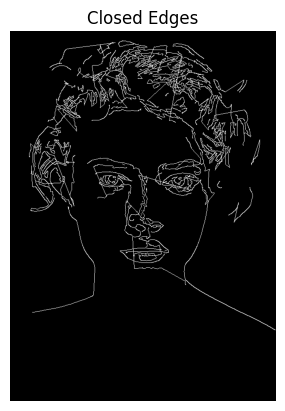

In [157]:
plot(closed, 'Closed Edges')

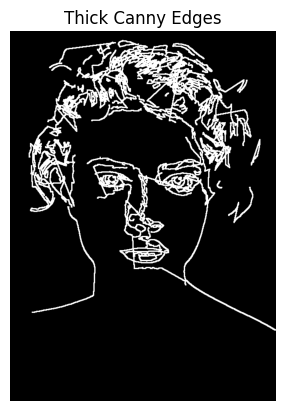

In [158]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
edges_thick = cv2.dilate(closed, kernel, iterations=1)

plot(edges_thick, 'Thick Canny Edges')

In [159]:
remaining_endpoints = np.argwhere((edges_thick == 255) & (neighbor_count2 == 1))

while len(remaining_endpoints) > 0:

    binary = closed // 255  # 0s and 1s, easier for neighbor counting

    # Count 8-connected neighbors for every edge pixel
    kernel = np.ones((3, 3), dtype=np.uint8)
    kernel[1, 1] = 0  # don't count the pixel itself

    neighbor_count = cv2.filter2D(binary.astype(np.float32), -1, kernel.astype(np.float32))
    neighbor_count = (neighbor_count * binary).astype(np.uint8)  # only count on edge pixels

    # Endpoint = edge pixel with exactly 1 neighbor
    endpoint_mask = (binary == 1) & (neighbor_count == 1)
    endpoint_coords = np.argwhere(endpoint_mask)  # array of [y, x] pairs

    closed = closed.copy()
    used = set()

    # Sort all pairs by distance, connect shortest gaps first
    pairs = []
    for i in range(len(endpoint_coords)):
        for j in range(i + 1, len(endpoint_coords)):
            y1, x1 = endpoint_coords[i]
            y2, x2 = endpoint_coords[j]
            dist = np.sqrt((y1 - y2)**2 + (x1 - x2)**2)
            pairs.append((dist, i, j))

    pairs.sort()

    for dist, i, j in pairs:
        if dist > 50000:  # max gap threshold
            break
        if i in used or j in used:
            continue
        y1, x1 = endpoint_coords[i]
        y2, x2 = endpoint_coords[j]
        cv2.line(closed, (x1, y1), (x2, y2), 255, thickness=1)
        used.add(i)
        used.add(j)

    # Re-detect endpoints on the new closed edge map — should be fewer
    binary2 = closed // 255
    neighbor_count2 = cv2.filter2D(binary2.astype(np.float32), -1, kernel.astype(np.float32))
    neighbor_count2 = (neighbor_count2 * binary2).astype(np.uint8)
    remaining_endpoints = np.argwhere((binary2 == 1) & (neighbor_count2 == 1))

    print(f"Endpoints before: {len(endpoint_coords)}, after: {len(remaining_endpoints)}")

Endpoints before: 120, after: 71
Endpoints before: 71, after: 68
Endpoints before: 68, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoints before: 62, after: 62
Endpoin

KeyboardInterrupt: 

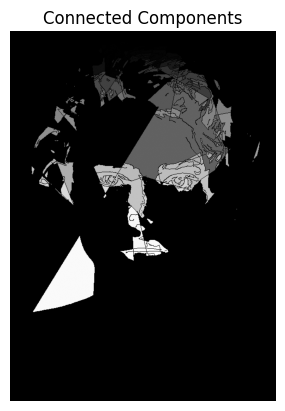

In [160]:
open_pixels = np.uint8(closed == 0) * 255

num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(open_pixels, connectivity=4)

plot(labels, 'Connected Components')

In [161]:
for region_id in range(1, num_labels):
    if stats[region_id, cv2.CC_STAT_AREA] < 80:
        labels[labels == region_id] = 0

In [162]:
pixels = img.reshape(-1, 3).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
_, kmeans_labels, centers = cv2.kmeans(pixels, 12, None, criteria, 5, cv2.KMEANS_RANDOM_CENTERS)

centers = np.uint8(centers)
quantized = centers[kmeans_labels.flatten()].reshape(img.shape)

In [163]:
output = np.zeros_like(img)

for region_id in range(1, num_labels):
    mask = (labels == region_id)
    if not mask.any():
        continue
    region_color = np.median(quantized[mask], axis=0).astype(np.uint8)
    output[mask] = region_color

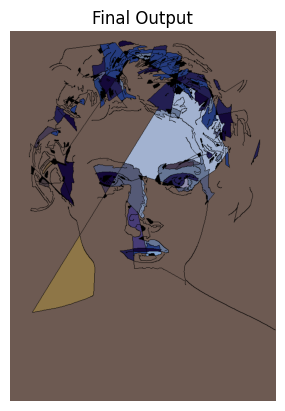

In [164]:
thin_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
thin_edges = cv2.erode(closed, thin_kernel, iterations=1)

output[thin_edges == 255] = [15, 15, 15]

plt.imshow(output)
plt.title('Final Output')
plt.axis('off')
plt.show()
# cv2.imwrite("output.png", output)